In [1]:
import numpy as np
from aeon.transformations.collection.convolution_based import MultiRocket
from aeon.transformations.collection.convolution_based._hydra import HydraTransformer
from aeon.utils.validation import check_n_jobs
from aeon.transformations.collection.interval_based import QUANTTransformer
import numpy as np
import polars as pl
from aeon.classification.base import BaseClassifier
from aeon.classification.feature_based import (
    Catch22Classifier,
)
import os
from aeon.transformations.collection.convolution_based import Rocket
from aeon.datasets.tsc_datasets import univariate
from sklearn.base import clone
from aeon.classification.convolution_based import MultiRocketHydraClassifier
from aeon.classification.convolution_based import RocketClassifier
from sklearn.metrics import accuracy_score
from aeon.classification.interval_based import QUANTClassifier
from autotsc import utils, models
from tqdm import tqdm
from aeon.classification.feature_based import Catch22Classifier
from aeon.classification.interval_based import QUANTClassifier
from aeon.classification.shapelet_based import RDSTClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeClassifierCV
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier


2025-12-16 08:47:46.085574: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
#from amltk.ensembling.weighted_ensemble_caruana import weighted_ensemble_caruana
#
#X1 = np.random.rand(m.test_pred1.shape[0], m.test_pred1.shape[1])
#X1 = X1 / X1.sum(axis=1, keepdims=True)
#
#X2 = np.random.rand(m.test_pred1.shape[0], m.test_pred1.shape[1])
#X2 = X2 / X2.sum(axis=1, keepdims=True)
#
#X3 = np.random.rand(m.test_pred1.shape[0], m.test_pred1.shape[1])
#X3 = X3 / X3.sum(axis=1, keepdims=True)
#
#model_predictions = {
#    'MR': m.test_pred1,
#    'QUANT': m.test_pred2,
#    'RDST': m.test_pred3,
#    'TEST': X1,
#    'TEST2': X2,
#    'TEST3': X3,
#}
#
#for k, v in model_predictions.items():
#    print(k, v.shape)
#
#def accuracy(y_true, y_pred):
#    # Convert to integers (0,1,2,3) for argmax comparison
#    # but *does not* affect predictions
#    unique = sorted(set(y_true))
#    mapping = {label: i for i, label in enumerate(unique)}
#    y_idx = np.array([mapping[x] for x in y_true])
#
#    y_hat = np.argmax(y_pred, axis=1)
#    return np.mean(y_hat == y_idx)
#
#weights, traj, final_pred = weighted_ensemble_caruana(
#    model_predictions=model_predictions,
#    targets=y_test,
#    size=350,                                  # ensemble size / num of draws
#    metric=accuracy,
#    select=max,
#)
#
#weights

In [3]:
df = pl.read_parquet("experiments/stacking_run_v1/*.parquet").filter(pl.col('model') != 'mixed-v2')
df

dataset,model,run,test_accuracy
str,str,i64,f64
"""ECG5000""","""mr-hydra""",200,0.946222
"""PLAID""","""quant""",300,0.947858
"""CricketY""","""mr-hydra""",300,0.846154
"""Beef""","""quant""",300,0.833333
"""EOGVerticalSignal""","""mr-hydra""",100,0.519337
…,…,…,…
"""Crop""","""quant""",200,0.777083
"""SwedishLeaf""","""quant""",300,0.9616
"""UWaveGestureLibraryAll""","""quant""",300,0.967895


In [4]:
from aeon.visualisation import plot_critical_difference

In [5]:
v = df.pivot(columns='model', values='test_accuracy', index='dataset', aggregate_function='mean').drop_nulls()
methods = df['model'].unique().to_list()
v

/tmp/ipykernel_4186192/1316611664.py:1: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  v = df.pivot(columns='model', values='test_accuracy', index='dataset', aggregate_function='mean').drop_nulls()


dataset,mr-hydra,quant,rdst,mixed-v3,mixed
str,f64,f64,f64,f64,f64
"""CricketY""",0.847863,0.806838,0.835043,0.842735,0.852137
"""Beef""",0.766667,0.8,0.833333,0.766667,0.744444
"""DodgerLoopWeekend""",0.984127,0.984127,0.984127,0.984127,0.984127
"""Chinatown""",0.975705,0.981535,0.977648,0.982507,0.981535
"""AllGestureWiimoteZ""",0.751905,0.654286,0.686667,0.745714,0.724762
…,…,…,…,…,…
"""Crop""",0.777877,0.776964,0.769544,0.79244,0.791607
"""ACSF1""",0.9,0.916667,0.91,0.936667,0.933333
"""ECG200""",0.913333,0.896667,0.903333,0.92,0.92


(<Figure size 600x240 with 1 Axes>, <Axes: >)

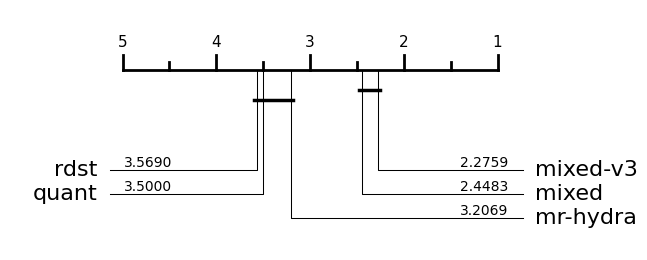

In [6]:
plot_critical_difference(v.select(methods).to_numpy(), methods)

In [7]:
def dataset_stats():
    import collections
    stats = []
    for dataset in univariate:
        X_train, y_train, X_test, y_test = utils.load_dataset(dataset)
        stats.append({'dataset': dataset,
                      'n_train': X_train.shape[0],
                      'n_test': X_test.shape[0],
                      'n_classes': len(np.unique(y_train)),
                      'series_length': X_train.shape[2],
                      })
    return pl.DataFrame(stats)

stats = dataset_stats()

In [8]:
joined = v.join(stats, on='dataset').sort('n_train')
joined

dataset,mr-hydra,quant,rdst,mixed-v3,mixed,n_train,n_test,n_classes,series_length
str,f64,f64,f64,f64,f64,i64,i64,i64,i64
"""DodgerLoopGame""",0.858268,0.868766,0.847769,0.860892,0.858268,17,127,2,288
"""DodgerLoopWeekend""",0.984127,0.984127,0.984127,0.984127,0.984127,18,126,2,288
"""BeetleFly""",0.9,0.816667,0.95,0.95,0.933333,20,20,2,512
"""BirdChicken""",0.9,0.9,0.9,0.9,0.9,20,20,2,512
"""Chinatown""",0.975705,0.981535,0.977648,0.982507,0.981535,20,343,2,24
…,…,…,…,…,…,…,…,…,…
"""DistalPhalanxOutlineAgeGroup""",0.757794,0.755396,0.791367,0.767386,0.788969,400,139,3,80
"""DistalPhalanxTW""",0.70024,0.681055,0.709832,0.729017,0.729017,400,139,6,80
"""ChlorineConcentration""",0.790712,0.752517,0.764236,0.781944,0.778299,467,3840,3,166


15


(<Figure size 600x240 with 1 Axes>, <Axes: >)

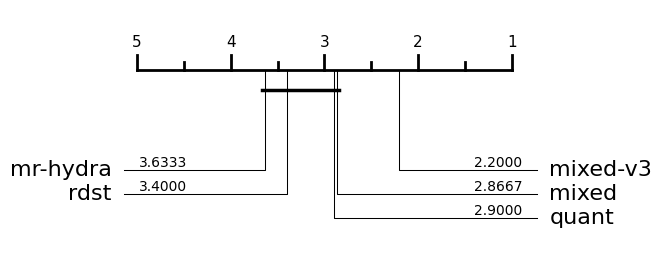

In [9]:
s_small = joined.filter(pl.col('n_train') < 200)
print(len(s_small))
plot_critical_difference(s_small.select(methods).to_numpy(), methods)

12


(<Figure size 600x240 with 1 Axes>, <Axes: >)

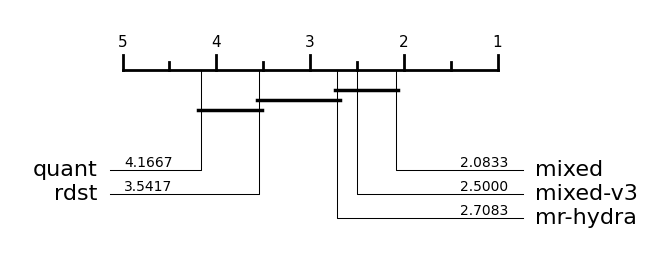

In [10]:
s_medium = joined.filter(pl.col('n_train') >= 200).filter(pl.col('n_train') < 600)
print(len(s_medium))
plot_critical_difference(s_medium.select(methods).to_numpy(), methods)

2


(<Figure size 600x240 with 1 Axes>, <Axes: >)

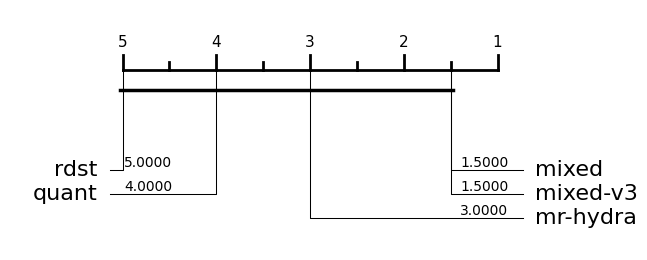

In [11]:
s_large = joined.filter(pl.col('n_train') >= 600)
print(len(s_large))
plot_critical_difference(s_large.select(methods).to_numpy(), methods)

In [12]:
s_large

dataset,mr-hydra,quant,rdst,mixed-v3,mixed,n_train,n_test,n_classes,series_length
str,f64,f64,f64,f64,f64,i64,i64,i64,i64
"""DistalPhalanxOutlineCorrect""",0.801932,0.78744,0.777778,0.805556,0.810386,600,276,2,80
"""Crop""",0.777877,0.776964,0.769544,0.79244,0.791607,7200,16800,24,46
